# HOUSE PRICE PREDICTION

# House Price Prediction

**Problem Statement:** Build a regression model to estimate house prices using size, location, bedrooms and other features.

**Dataset:** Ames Housing dataset (`train.csv` and `test.csv`)

**Student Tasks:**
- Explore numerical and categorical features
- Handle missing values
- Encode categories
- Split data into training and testing sets
- Train Linear Regression and Decision Tree models
- Compare MAE, RMSE and R²

**Expected Learning Outcomes:** Regression, Feature preprocessing, Model evaluation, Train-test split, Comparing algorithms.


## 1. Import Libraries


In [1]:
# Import libraries needed for data handling, preprocessing, and modeling
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the Dataset


In [3]:
# Load training and test CSV files (we only use train.csv for model building and evaluation)
train_data_path = "/Users/jellyfish/Documents/Developer/DataScience2026/Datasets/data_set_HP/train.csv"
test_data_path = "/Users/jellyfish/Documents/Developer/DataScience2026/Datasets/data_set_HP/test.csv"

df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)

# Show dataset shape: rows x columns
print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)


Training set shape: (1460, 81)
Test set shape: (1459, 80)


## 3. Quick Look at the Data


In [4]:
# Display first 5 rows to understand columns and values
print(df_train.head())

# Show column names, data types, and non-null counts
print(df_train.info())


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

## 4. Explore Numerical Features

In [5]:
# Select all numerical columns (int and float types)
numerical_features = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove Id (just an identifier) and SalePrice (our target variable)
numerical_features = [col for col in numerical_features if col not in ["Id", "SalePrice"]]

print(f"Number of numerical features: {len(numerical_features)}")
print("Numerical features:", numerical_features)


Number of numerical features: 36
Numerical features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [6]:
# Statistical summary of numerical features (mean, std, min, max, etc.)
df_train[numerical_features].describe()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [7]:
# Check how the target variable (SalePrice) is distributed
print("SalePrice statistics:")
print(df_train["SalePrice"].describe())


SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 5. Explore Categorical Features


In [8]:
# Select all categorical/text columns (object type)
categorical_features = df_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of categorical features: {len(categorical_features)}")
print("Categorical features:", categorical_features)


Number of categorical features: 43
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [ ]:
# Show unique value counts for a few important categorical features
important_cat = ["MSZoning", "Neighborhood", "HouseStyle", "SaleCondition"]
for col in important_cat:
    print(f"\n{col} - unique values: {df_train[col].nunique()}")
    print(df_train[col].value_counts().head())


## 6. Check Missing Values


In [9]:
# Count missing values in each column
missing_count = df_train.isnull().sum()
missing_percent = (missing_count / len(df_train)) * 100

# Show only columns that have missing values, sorted by percentage
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
missing_df.head(15)


Total columns with missing values: 19


,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## 7. Handle Missing Values


In [10]:
# Create a working copy so we do not modify the original dataset file
df = df_train.copy()

# Step 1: For features where 'missing' has meaning (no basement, no garage, etc.), fill with 'NA'
na_fill_columns = [
    "Alley", "FireplaceQu", "PoolQC", "Fence", "MiscFeature",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond"
]
for col in na_fill_columns:
    df[col] = df[col].fillna("NA")

# Step 2: For other categorical columns, fill missing values with the most frequent value (mode)
for col in categorical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Step 3: For basement/garage numerical features, fill with 0 (means feature does not exist)
zero_fill_columns = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageCars", "GarageArea"
]
for col in zero_fill_columns:
    df[col] = df[col].fillna(0)

# Step 4: For remaining numerical columns, fill with median (middle value)
for col in numerical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Verify no missing values remain
print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 8. Encode Categorical Features


In [11]:
# Part A: Ordinal encoding - convert quality/rating columns to ordered numbers
# Lower number = lower quality, higher number = higher quality
ordinal_columns = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC": ["NA", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "PavedDrive": ["N", "P", "Y"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}

for col, categories in ordinal_columns.items():
    df[col] = df[col].astype(CategoricalDtype(categories=categories, ordered=True)).cat.codes

print("Ordinal encoding done for quality/rating columns.")


Ordinal encoding done for quality/rating columns.


In [12]:
# Part B: Treat some numerical columns as categories (year, class, month are labels, not continuous numbers)
numeric_as_category = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
for col in numeric_as_category:
    df[col] = df[col].astype(str)

# Part C: One-hot encoding - create binary columns for each category value
remaining_object_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Columns to one-hot encode: {len(remaining_object_cols)}")

df_encoded = pd.get_dummies(df, columns=remaining_object_cols, drop_first=True)
print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")


Columns to one-hot encode: 32
Shape before encoding: (1460, 81)
Shape after encoding:  (1460, 500)


## 9. Prepare Features (X) and Target (y)


In [13]:
# X = all input features, y = SalePrice (what we want to predict)
X = df_encoded.drop(["Id", "SalePrice"], axis=1)
y = df_encoded["SalePrice"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (1460, 498)
Target vector shape: (1460,)


## 10. Split Data into Training and Testing Sets

In [14]:
# Split 80% for training, 20% for testing (random_state keeps results reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0], "samples")
print("Testing set size: ", X_test.shape[0], "samples")


Training set size: 1168 samples
Testing set size:  292 samples


## 11. Feature Scaling (for Linear Regression)


In [15]:
# StandardScaler makes features have mean=0 and std=1 (helps Linear Regression perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scaling from training data
X_test_scaled = scaler.transform(X_test)           # apply same scaling to test data

print("Scaling complete. Linear Regression will use scaled data.")


Scaling complete. Linear Regression will use scaled data.


## 12. Train Linear Regression Model


In [16]:
# Linear Regression finds the best straight-line relationship between features and price
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict house prices on the test set
lr_predictions = lr_model.predict(X_test_scaled)

print("Linear Regression training complete.")


Linear Regression training complete.


## 13. Train Decision Tree Model


In [17]:
# Decision Tree splits data into branches based on feature values to predict price
# max_depth and min_samples_leaf prevent overfitting (memorizing training data)
dt_model = DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)  # Decision Tree does not need scaled features

# Predict house prices on the test set
dt_predictions = dt_model.predict(X_test)

print("Decision Tree training complete.")


Decision Tree training complete.


## 14. Visualize Model Predictions

Simple plots to see how well each model predicts house prices on the test set.

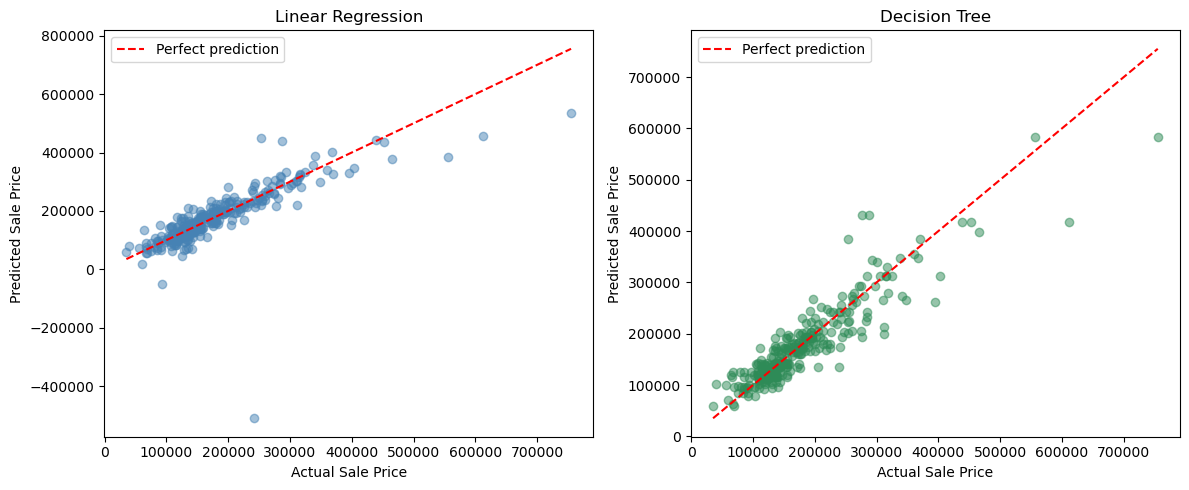

In [19]:
# Plot Actual vs Predicted prices for both models
# Points close to the red dashed line mean better predictions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression plot
axes[0].scatter(y_test, lr_predictions, alpha=0.5, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Sale Price")
axes[0].set_ylabel("Predicted Sale Price")
axes[0].set_title("Linear Regression")
axes[0].legend()

# Decision Tree plot
axes[1].scatter(y_test, dt_predictions, alpha=0.5, color="seagreen")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
axes[1].set_xlabel("Actual Sale Price")
axes[1].set_ylabel("Predicted Sale Price")
axes[1].set_title("Decision Tree")
axes[1].legend()

plt.tight_layout()
plt.show()

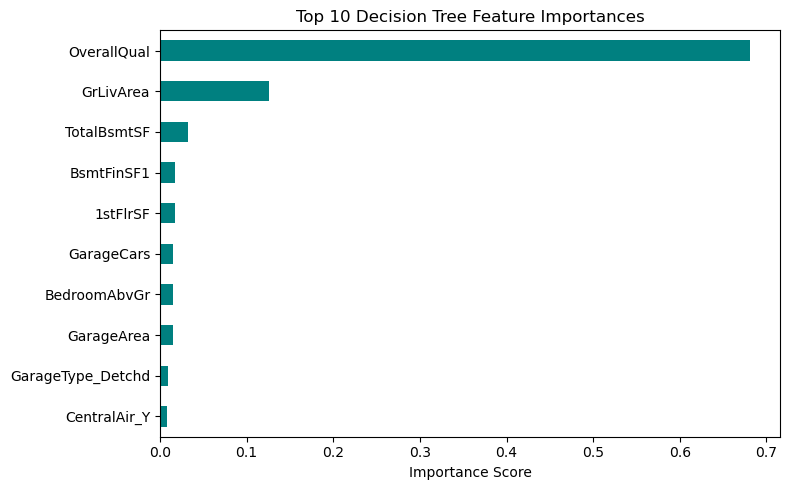

In [20]:
# Show top 10 most important features used by the Decision Tree
# Higher bar = feature has more influence on the predicted price
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh", color="teal")
plt.xlabel("Importance Score")
plt.title("Top 10 Decision Tree Feature Importances")
plt.gca().invert_yaxis()  # show most important feature at the top
plt.tight_layout()
plt.show()

## 15. Compare Models - MAE, RMSE, and R²


In [21]:
# Function to calculate all three evaluation metrics for a model
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

# Evaluate both models on the test set
results = [
    evaluate_model(y_test, lr_predictions, "Linear Regression"),
    evaluate_model(y_test, dt_predictions, "Decision Tree"),
]

# Display results in a clean table
results_df = pd.DataFrame(results)
results_df["MAE"] = results_df["MAE"].round(0)
results_df["RMSE"] = results_df["RMSE"].round(0)
results_df["R2"] = results_df["R2"].round(4)
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,25815.0,57247.0,0.5727
1,Decision Tree,23683.0,36151.0,0.8296


In [22]:
# Print a readable summary of which model performed better

print("MODEL COMPARISON SUMMARY")

for _, row in results_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  MAE  (Mean Absolute Error):     ${row['MAE']:,.0f}")
    print(f"  RMSE (Root Mean Squared Error): ${row['RMSE']:,.0f}")
    print(f"  R²   (Coefficient of Determination): {row['R2']}")


print("Lower MAE/RMSE = better predictions")
print("Higher R² (closer to 1) = model explains more variance")



MODEL COMPARISON SUMMARY

Linear Regression:
  MAE  (Mean Absolute Error):     $25,815
  RMSE (Root Mean Squared Error): $57,247
  R²   (Coefficient of Determination): 0.5727

Decision Tree:
  MAE  (Mean Absolute Error):     $23,683
  RMSE (Root Mean Squared Error): $36,151
  R²   (Coefficient of Determination): 0.8296
Lower MAE/RMSE = better predictions
Higher R² (closer to 1) = model explains more variance
